In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/noorulainzahid/housing-dataset-for-ridge-lasso/housing_ridge_lasso_dataset - housing_ridge_lasso_dataset.csv


In [5]:
# This is the standard way to load data in a Kaggle Notebook
path = "/kaggle/input/datasets/noorulainzahid/housing-dataset-for-ridge-lasso/housing_ridge_lasso_dataset - housing_ridge_lasso_dataset.csv"

df = pd.read_csv(path)

print("First 5 records:")
print(df.head())

First 5 records:
   bedrooms  bathrooms  square_footage  property_age  distance_to_city  \
0         4        3.1     1685.700042            24         11.907545   
1         5        1.2     1302.825313            30         24.723702   
2         3        1.9      518.833171            49         29.099982   
3         5        3.1     1704.486119            19         13.890821   
4         5        1.2     3006.307711            43         15.456489   

   crime_rate  school_quality  transport_access  employment_rate  \
0    3.096524        4.217227          7.295900        93.678885   
1    4.730712        1.593046          5.191932        78.553374   
2    2.800660        2.503501          5.608285        90.442415   
3    4.689159        9.935477          2.232269        80.983423   
4    8.889595        6.067116          4.069154        68.909951   

   median_income  commercial_proximity  property_tax_rate  \
0    31867.86356             13.594185           1.811360   
1    70

Loading dataset and showing its first 5 rows to understand its structure.


In [6]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   bedrooms              1500 non-null   int64  
 1   bathrooms             1500 non-null   float64
 2   square_footage        1500 non-null   float64
 3   property_age          1500 non-null   int64  
 4   distance_to_city      1500 non-null   float64
 5   crime_rate            1500 non-null   float64
 6   school_quality        1500 non-null   float64
 7   transport_access      1500 non-null   float64
 8   employment_rate       1500 non-null   float64
 9   median_income         1500 non-null   float64
 10  commercial_proximity  1500 non-null   float64
 11  property_tax_rate     1500 non-null   float64
 12  environment_quality   1500 non-null   float64
 13  total_rooms           1500 non-null   float64
 14  living_area_index     1500 non-null   float64
 15  income_index         

* A dataset of 1500 housing records with 17 features,
* no missing values, 
* and house_price is the target variable—ready for analysis or regression modeling.

In [7]:
df.describe()

,bedrooms,bathrooms,square_footage,property_age,distance_to_city,crime_rate,school_quality,transport_access,employment_rate,median_income,commercial_proximity,property_tax_rate,environment_quality,total_rooms,living_area_index,income_index,house_price
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,2.988000,2.493200,1806.757033,24.050000,15.212113,5.146992,5.498877,5.437555,80.168640,59472.789775,10.243219,1.722627,5.489723,2.964621,1811.248413,5.980399,366116.810041
std,1.435234,0.868072,505.264119,14.275177,8.530100,2.897727,2.574681,2.574214,11.534664,15294.855716,5.556892,0.714038,2.622358,1.477210,552.080324,1.790341,85198.229654
min,1.000000,1.000000,500.000000,0.000000,0.518512,0.115636,1.001667,1.009201,60.004746,20000.000000,0.503423,0.501058,1.000084,-0.208254,436.481880,-0.134041,82783.722500
25%,2.000000,1.775000,1454.222059,12.000000,7.994157,2.707555,3.334012,3.305119,70.101112,48610.112528,5.649468,1.087903,3.203361,1.748574,1432.686286,4.820385,308640.339100
50%,3.000000,2.500000,1807.472850,23.000000,15.438394,5.202481,5.547073,5.388615,80.697945,59589.229765,10.045042,1.730211,5.494510,2.945314,1791.462785,5.929810,365228.264050
75%,4.000000,3.200000,2142.026964,36.000000,22.263989,7.674215,7.730096,7.587658,90.120497,69835.980075,14.853405,2.320400,7.754939,4.235569,2176.205221,7.201074,421565.355675
max,5.000000,4.000000,3763.118853,49.000000,29.995553,9.997439,9.995467,9.996721,99.963631,107333.068200,19.965756,2.996808,9.997253,6.109949,3676.765291,11.878311,622605.559500


A summary of 1500 housing records showing :
* average, spread, and range of each feature,
* suitable for analysis and price prediction.

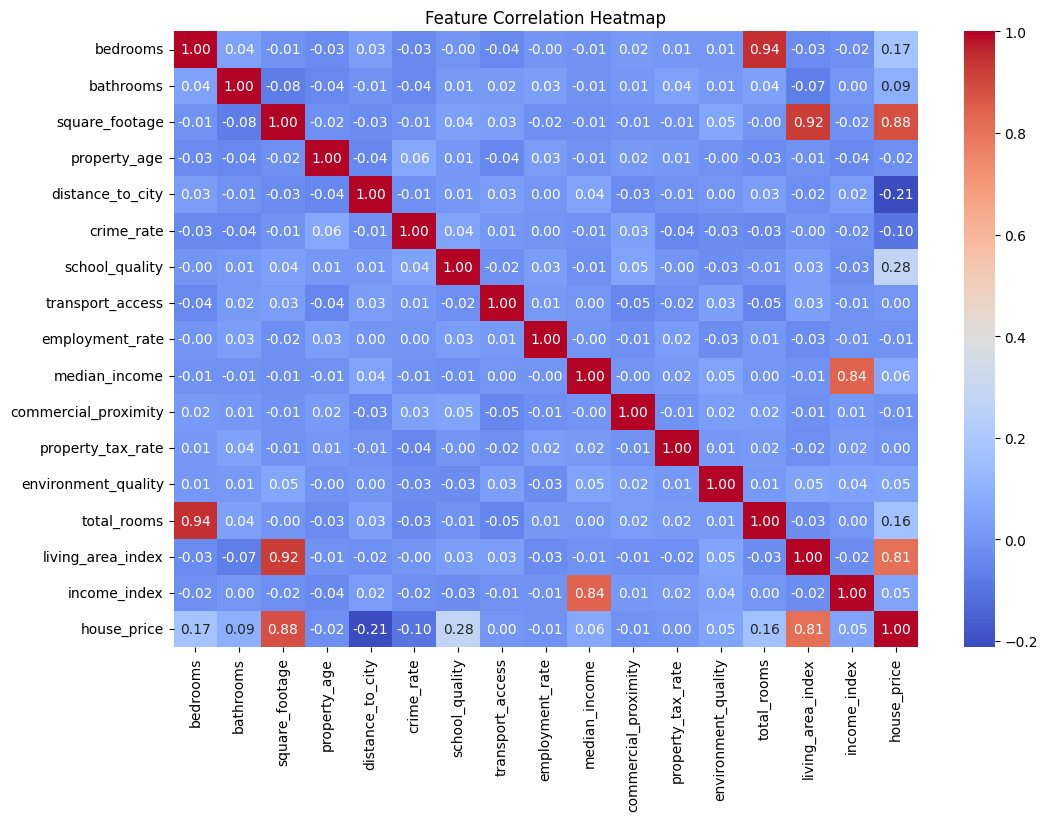

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = df.corr()

# Display the correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

Correlation matrix gives the correlation of variables and we can clearly see values howing high correlation.


In [10]:
# Calculate the correlation matrix
corr_matrix = df.corr()

# Create a tidy table of correlation pairs
# We unstack it and reset the index to get 'Variable 1', 'Variable 2', 'Correlation'
corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlation']

# 1. Remove self-correlation (Variable A vs Variable A)
# 2. Keep only high correlations (Absolute value > 0.75)
# 3. Sort by strongest correlation
high_corr = corr_pairs[
    (corr_pairs['Variable 1'] != corr_pairs['Variable 2']) & 
    (corr_pairs['Correlation'].abs() > 0.75)
].sort_values(by='Correlation', ascending=False)

# Remove duplicates (e.g., A vs B and B vs A are the same)
high_corr = high_corr.iloc[::2]

print("Variables with High Correlation (> 0.75):")
print(high_corr.to_string(index=False))

Variables with High Correlation (> 0.75):
       Variable 1        Variable 2  Correlation
         bedrooms       total_rooms     0.943909
   square_footage living_area_index     0.920894
   square_footage       house_price     0.882495
    median_income      income_index     0.841465
living_area_index       house_price     0.806323


Strong relationships between some features (like size, rooms, and price) show overlapping information that may affect model performance (multicollinearity).

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Assuming 'house_price' is the target
X = df.drop('house_price', axis=1)
y = df['house_price']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Splits the dataset into training (80%) and testing (20%) sets, then standardizes the features so they are on the same scale for better model performance.

## Linear Regression

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Create the OLS regression model
ols_model = LinearRegression()

# Fit the model on training data
ols_model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred = ols_model.predict(X_train_scaled)
y_test_pred = ols_model.predict(X_test_scaled)

# Evaluate the model
print("Training R2:", r2_score(y_train, y_train_pred))
print("Test R2:", r2_score(y_test, y_test_pred))
print("Training MSE:", mean_squared_error(y_train, y_train_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))

# Inspect coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': ols_model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(coef_df)

Training R2: 0.9459596830737763
Test R2: 0.9480166754005137
Training MSE: 402327076.01003146
Test MSE: 336099965.8865985
                 Feature   Coefficient
2         square_footage  75781.255140
6         school_quality  21070.778663
4       distance_to_city -16683.364072
0               bedrooms  16495.253123
1              bathrooms  12275.449079
5             crime_rate  -7636.158108
9          median_income   7362.056956
13           total_rooms  -1897.668642
10  commercial_proximity  -1678.062417
14     living_area_index    697.237847
8        employment_rate   -407.087205
7       transport_access   -284.052746
3           property_age    279.504183
11     property_tax_rate   -140.625675
15          income_index    -89.380265
12   environment_quality    -29.868410


The model fits the data very well (R² ≈ 0.95 for both training and test, with low MSE), meaning it can explain most of the variation in house prices.

Most influential features:
* Positive impact: square_footage, school_quality, bedrooms, bathrooms, median_income — higher values increase house price.
* Negative impact: distance_to_city, crime_rate — higher values decrease house price.
Unexpected signs:
* total_rooms has a negative coefficient, likely due to multicollinearity with bedrooms and square_footage.

Using Ridge or Lasso regression can help stabilize coefficients, reduce multicollinearity effects, and make interpretation more logical.

## Ridge Regression

In [13]:
from sklearn.linear_model import Ridge

# Create Ridge regression model with a regularization strength alpha (λ)
ridge_model = Ridge(alpha=0.5)  # you can adjust alpha later

# Fit the model
ridge_model.fit(X_train_scaled, y_train)

# Make predictions
y_train_ridge = ridge_model.predict(X_train_scaled)
y_test_ridge = ridge_model.predict(X_test_scaled)

# Evaluate performance
from sklearn.metrics import mean_squared_error, r2_score

print("Ridge Training R2:", r2_score(y_train, y_train_ridge))
print("Ridge Test R2:", r2_score(y_test, y_test_ridge))
print("Ridge Training MSE:", mean_squared_error(y_train, y_train_ridge))
print("Ridge Test MSE:", mean_squared_error(y_test, y_test_ridge))

# Inspect Ridge coefficients
ridge_coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': ridge_model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(ridge_coef_df)

Ridge Training R2: 0.9459586712058533
Ridge Test R2: 0.9480180547505951
Ridge Training MSE: 402334609.30898243
Ridge Test MSE: 336091047.6513974
                 Feature   Coefficient
2         square_footage  75561.979836
6         school_quality  21065.231144
4       distance_to_city -16675.789500
0               bedrooms  16429.117218
1              bathrooms  12269.731656
5             crime_rate  -7634.449916
9          median_income   7341.301266
13           total_rooms  -1830.119839
10  commercial_proximity  -1676.746190
14     living_area_index    899.187902
8        employment_rate   -407.850598
7       transport_access   -286.319966
3           property_age    276.384932
11     property_tax_rate   -138.616597
15          income_index    -72.032070
12   environment_quality    -26.854275


1. Model performance:
* R² ~ 0.95 for both training and test → model still explains ~95% of price variation
* MSE is low → predictions are close to actual prices
* Performance is very similar to OLS, showing that Ridge fits well

2. Coefficients

Ridge shrinks large coefficients slightly compared to OLS to reduce multicollinearity effects:
* square_footage, school_quality, bedrooms still have the largest positive impact on house price
* distance_to_city and crime_rate remain negative influencers
* total_rooms negative effect is slightly reduced (-1830 vs -1897 in OLS) → Ridge stabilizes overlapping features

3. Key idea
* Ridge doesn’t eliminate features, but reduces extreme coefficients caused by correlated variables
* Helps make the model more stable and robust without losing predictive power


## Lasso Rgression

In [19]:
from sklearn.linear_model import Lasso

# Create Lasso model with some regularization strength alpha (λ)
lasso_model = Lasso(alpha=1.0)  # you can adjust alpha to be stronger or weaker

# Fit the model
lasso_model.fit(X_train_scaled, y_train)

# Make predictions
y_train_lasso = lasso_model.predict(X_train_scaled)
y_test_lasso = lasso_model.predict(X_test_scaled)

# Evaluate performance
print("Lasso Training R2:", r2_score(y_train, y_train_lasso))
print("Lasso Test R2:", r2_score(y_test, y_test_lasso))
print("Lasso Training MSE:", mean_squared_error(y_train, y_train_lasso))
print("Lasso Test MSE:", mean_squared_error(y_test, y_test_lasso))

# Inspect Lasso coefficients
lasso_coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso_model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(lasso_coef_df)

Lasso Training R2: 0.945959675017533
Lasso Test R2: 0.9480160302331292
Lasso Training MSE: 402327135.9883037
Lasso Test MSE: 336104137.2384232
                 Feature   Coefficient
2         square_footage  75780.031497
6         school_quality  21070.054325
4       distance_to_city -16682.277703
0               bedrooms  16477.681083
1              bathrooms  12274.234541
5             crime_rate  -7635.011274
9          median_income   7355.472490
13           total_rooms  -1880.174927
10  commercial_proximity  -1677.202929
14     living_area_index    697.187416
8        employment_rate   -406.065175
7       transport_access   -282.970038
3           property_age    278.502883
11     property_tax_rate   -139.749048
15          income_index    -83.483437
12   environment_quality    -28.753927


Model performance:
* Training R² ≈ 0.946, Test R² ≈ 0.948 → The model still explains ~95% of house price variation.
* Training MSE ≈ 402 million, Test MSE ≈ 336 million → Predictions remain accurate.

Feature impact:
* Strong positive drivers: square_footage, school_quality, bedrooms, bathrooms, median_income
* Negative drivers: distance_to_city, crime_rate
* Less important features now have slightly smaller coefficients, showing * Lasso is shrinking redundant features more strongly.

Key takeaway:
* Increasing α reduces coefficients of minor features further, improving model simplicity and robustness, while maintaining high predictive accuracy.

## Comparison of three Models

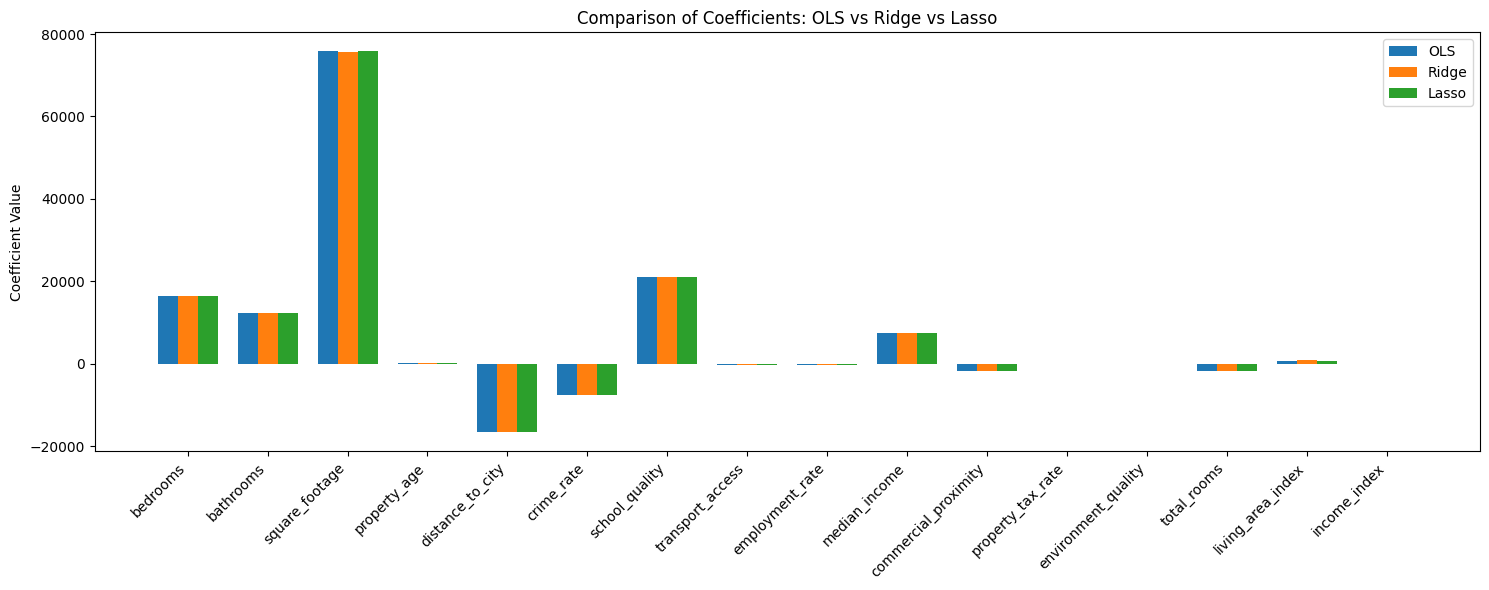

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Combine coefficients into one array
coef_matrix = np.vstack([ols_model.coef_, ridge_model.coef_, lasso_model.coef_])
labels = ['OLS', 'Ridge', 'Lasso']

# If you want Lasso coefficients with alpha=0.5, make sure you have `lasso_model.coef_`
coef_matrix = np.vstack([ols_model.coef_, ridge_model.coef_, lasso_model.coef_])

# Plot
plt.figure(figsize=(15,6))
x = np.arange(len(X.columns))
width = 0.25

plt.bar(x - width, ols_model.coef_, width, label='OLS')
plt.bar(x, ridge_model.coef_, width, label='Ridge')
plt.bar(x + width, lasso_model.coef_, width, label='Lasso')

plt.xticks(x, X.columns, rotation=45, ha='right')
plt.ylabel('Coefficient Value')
plt.title('Comparison of Coefficients: OLS vs Ridge vs Lasso')
plt.legend()
plt.tight_layout()
plt.show()

1. Bar Height = Feature Importance
Tall bars → feature has a big effect on the target (e.g., house price).
Short bars → feature has little effect.
Negative bars → feature reduces the target value.
2. Color Differences = Model Behavior
Blue (Linear/OLS): classic model, just fits the data directly.
Orange (Ridge): shrinks all coefficients a little to avoid overreacting to noise.
Green (Lasso): can shrink small/weak features all the way to zero, ignoring them completely.
